# Music Support Bot Notebook

## Setup

In [25]:
import operator
import sqlite3
import textwrap
from enum import Enum
from typing import Annotated, Literal

import requests
from IPython.display import Image, display
from langchain_community.utilities.sql_database import SQLDatabase
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import END, START, StateGraph
from langgraph.types import Command, interrupt
from pydantic import BaseModel, Field
from sqlalchemy import create_engine
from sqlalchemy.pool import StaticPool

In [26]:
# Database setup
def get_engine_for_chinook_db():
    """Pull sql file, populate in-memory database, and create engine."""
    url = "https://raw.githubusercontent.com/lerocha/chinook-database/master/ChinookDatabase/DataSources/Chinook_Sqlite.sql"
    response = requests.get(url)
    sql_script = response.text

    connection = sqlite3.connect(":memory:", check_same_thread=False)
    connection.executescript(sql_script)
    return create_engine(
        "sqlite://",
        creator=lambda: connection,
        poolclass=StaticPool,
        connect_args={"check_same_thread": False},
    )


engine = get_engine_for_chinook_db()
db = SQLDatabase(engine)


@tool
def recommend_songs_by_genre(genre: str):
    """Recommend songs by genre."""
    print(f"recommend_songs_by_genre: {genre}")
    return db.run(
        f"""
        SELECT Track.Name as SongName, Genre.Name as GenreName
        FROM Track
        LEFT JOIN Genre ON Track.GenreId = Genre.GenreId
        WHERE Genre.Name LIKE '%{genre}%';
        """,
        include_columns=True,
    )


@tool
def get_albums_by_artist(artist: str):
    """Get albums by an artist."""
    print(f"get_albums_by_artist: {artist}")
    return db.run(
        f"""
        SELECT * FROM public.artist
        ORDER BY artist_id ASC 
        """,
        include_columns=True,
    )


@tool
def get_tracks_by_artist(artist: str):
    """Get songs by an artist (or similar artists)."""
    print(f"get_tracks_by_artist: {artist}")
    return db.run(
        f"""
        SELECT Track.Name as SongName, Artist.Name as ArtistName
        FROM Album
        LEFT JOIN Artist ON Album.ArtistId = Artist.ArtistId
        LEFT JOIN Track ON Track.AlbumId = Album.AlbumId
        WHERE Artist.Name LIKE '%{artist}%';
        """,
        include_columns=True,
    )


@tool
def check_for_songs(song_title: str):
    """Check if a song exists by its name."""
    print(f"check_for_songs: {song_title}")
    return db.run(
        f"""
        SELECT * FROM Track WHERE Name LIKE '%{song_title}%';
        """,
        include_columns=True,
    )


@tool
def check_for_songs_by_genre(genre_name: str):
    """Check for songs that belong to a genre by genre name."""
    print(f"check_for_songs_by_genre: {genre_name}")
    return db.run(
        f"""
        SELECT
            t.TrackId,
            t.Name AS TrackName,
            g.Name AS GenreName,
            al.Title AS AlbumTitle,
            ar.Name AS ArtistName,
            t.Composer,
            t.Milliseconds,
            t.Bytes,
            t.UnitPrice
        FROM Track t
        JOIN Genre g
            ON t.GenreId = g.GenreId
        LEFT JOIN Album al
            ON t.AlbumId = al.AlbumId
        LEFT JOIN Artist ar
            ON al.ArtistId = ar.ArtistId
        WHERE g.Name LIKE '%{genre_name}%'
        ORDER BY ar.Name, al.Title, t.Name;
        """,
        include_columns=True,
    )


# TODO: can use playlist to find similar tracks


# TODO: songs in genre by that artist
# SELECT
#   ar.artist_id,
#   ar.name AS artist_name,
#   COUNT(*) AS track_count
# FROM public.genre AS g
# JOIN public.track AS t
#   ON g.genre_id = t.genre_id
# JOIN public.album AS al
#   ON t.album_id = al.album_id
# JOIN public.artist AS ar
#   ON al.artist_id = ar.artist_id
# WHERE g.name = 'Rock'
# GROUP BY ar.artist_id, ar.name
# ORDER BY track_count DESC, ar.name ASC;

In [52]:
class MusicQuery(BaseModel):
    artist: list[str] | None = Field(default=None, description="The names of artists mentioned in the message")
    album: list[str] | None = Field(default=None, description="The names of albums mentioned in the message")
    song: list[str] | None = Field(default=None, description="The names of songs mentioned in the message")
    genre: list[str] | None = Field(default=None, description="The genres of music mentioned in the message")


class MessageClassification(BaseModel):
    intent: Literal["music_query", "customer_support", "other"]


class MessageAgentState(BaseModel):
    # Raw message data
    message_content: str
    message_id: int
    sender_number: str

    # Classification result
    message_classification: MessageClassification | None = None

    # Music query
    music_query: MusicQuery | None = None
    search_results: Annotated[list[str], operator.add] = Field(default_factory=list)

## Define Nodes

In [53]:
# Setup LLM
reasoning = {
    "effort": "low",  # 'low', 'medium', or 'high'
    "summary": None,  # 'detailed', 'auto', or None
}

llm = ChatOpenAI(model="gpt-5-nano", reasoning=reasoning)

In [54]:
# -----------------------------------------------------------------------------
# Classify intent
# -----------------------------------------------------------------------------


def classify_intent(state: MessageAgentState) -> MessageAgentState:
    """Use LLM to classify email intent and urgency, then route accordingly"""

    # Create structured LLM that returns MessageClassification
    structured_llm = llm.with_structured_output(MessageClassification)

    classification_prompt = textwrap.dedent(
        f"""
        You are a routing classifier for an application that handles either music requests or customer support.

        Your job is to classify the user's message into exactly one intent:
        - "music_query"
        - "customer_support"
        - "other"

        Message to classify:
        {state.message_content}

        Classification rules:

        1. music_query
        Use this when the user is asking about music in any way, including:
        - song recommendations
        - music similar to an artist, song, album, or playlist
        - genres, moods, vibes, playlists, tracks, albums, artists
        - finding songs by genre, artist, or style
        - requests like "find me music like AC/DC"

        Examples of music_query:
        - "Find me music like AC/DC"
        - "Recommend songs similar to Yellow"
        - "Give me some jazz albums"
        - "What artists sound like Radiohead?"
        - "Make me a workout playlist"
        - "Show me rock songs"

        2. customer_support
        Use this only when the user is asking for help with a product, service, or account issue, including:
        - billing
        - login or password problems
        - subscription issues
        - bug reports
        - account access
        - technical support

        Examples of customer_support:
        - "I can't log into my account"
        - "Why was I charged twice?"
        - "My subscription is not working"
        - "The app keeps crashing"
        - "Help me reset my password"

        3. other
        Use this when the message is neither a music request nor a customer support request, or when it is too vague to classify confidently.

        Examples of other:
        - "Hello"
        - "How are you?"
        - "Tell me a joke"
        - "I need help"   # too vague without context

        Important instructions:
        - If the message asks for music, recommendations, artists, albums, songs, genres, or playlists, classify it as "music_query".
        - Do not classify something as customer_support unless it clearly refers to an account, billing, subscription, login, app issue, or technical problem.
        - When in doubt between music_query and other, prefer music_query if there is any clear music-related request.
        - Return only the structured classification.
    """
    )

    # Get structured output from LLM
    message_classification = structured_llm.invoke(classification_prompt)
    state.message_classification = message_classification

    return state


def route_after_classification(
    state: MessageAgentState,
) -> Literal["customer_support_query", "parse_music_query", "__end__"]:
    print("Routing based on classification:", state.message_classification)
    if (
        state.message_classification
        and state.message_classification.intent == "customer_support"
    ):
        return "customer_support_query"
    if (
        state.message_classification
        and state.message_classification.intent == "parse_music_query"
    ):
        return "parse_music_query"
    return END


# -----------------------------------------------------------------------------
# Music recommendation query parsing
# -----------------------------------------------------------------------------


def parse_music_query(state: MessageAgentState) -> dict:
    structured_llm = llm.with_structured_output(MusicQuery)

    prompt = textwrap.dedent(
        f"""
    Analyze this customer message and extract music query information.

    Message: {state.message_content}

    Extract the following information if present:
    - artist: the name of the artist mentioned in the message, or None if not mentioned
    - album: the name of the album mentioned in the message, or None if not mentioned
    - song: the name of the song mentioned in the message, or None if not mentioned
    """
    )

    music_query = structured_llm.invoke(prompt)
    return {"music_query": music_query}


genre_names = [
    "Rock",
    "Jazz",
    "Metal",
    "Alternative & Punk",
    "Rock And Roll",
    "Blues",
    "Latin",
    "Reggae",
    "Pop",
    "Soundtrack",
    "Bossa Nova",
    "Easy Listening",
    "Heavy Metal",
    "R&B/Soul",
    "Electronica/Dance",
    "World",
    "Hip Hop/Rap",
    "Science Fiction",
    "TV Shows",
    "Sci Fi & Fantasy",
    "Drama",
    "Comedy",
    "Alternative",
    "Classical",
    "Opera",
]


class GenreExtraction(BaseModel):
    genres: list[str] | None = Field(
        default=None,
        description="List of music genres identified from the message",
    )


def identify_genre_from_message(state: MessageAgentState) -> dict:
    structured_llm = llm.with_structured_output(GenreExtraction)
    prompt = textwrap.dedent(
        f"""
    Extract music genres from this message. Only use genres from this list:
    {", ".join(genre_names)}

    Message: {state.message_content}

    If no genre is mentioned or can be inferred from the artists, songs, or albums mentioned, return None.
    Return each genre only once — no duplicates.
    """
    )
    result = structured_llm.invoke(prompt)

    # Deduplicate while preserving order
    genres = list(dict.fromkeys(result.genres)) if result.genres else None
    print("Identified genres:", genres)

    updated_query = (
        state.music_query.model_copy(update={"genre": genres})
        if state.music_query
        else MusicQuery(genre=genres)
    )
    print({"music_query": updated_query})
    return {"music_query": updated_query}


def search_for_songs_by_genre(state: MessageAgentState) -> dict:
    print("Searching for songs by genre:", state.music_query.genre)
    if state.music_query and state.music_query.genre:
        songs = []
        for genre in state.music_query.genre:
            songs.extend(check_for_songs_by_genre(genre))
            print("Songs found:", songs)
        return {"search_results": [f"Songs by genre:\n{songs}"]}
    return {}


# -----------------------------------------------------------------------------
# Customer support query
# -----------------------------------------------------------------------------


def customer_support_query(state: MessageAgentState) -> MessageAgentState:
    """Handle customer support queries based on classified intent and topic"""
    print("Handling customer support query for:", state.message_content)
    return state

## Build the graph

In [55]:
# Memory
memory = InMemorySaver()


# Build graph
builder = StateGraph(MessageAgentState)


# Add nodes
builder.add_node("classify_intent", classify_intent)
builder.add_node("customer_support_query", customer_support_query)
builder.add_node("parse_music_query", parse_music_query)

builder.add_node("identify_genre_from_message", identify_genre_from_message)
builder.add_node("search_for_songs_by_genre", search_for_songs_by_genre)
# builder.add_node("search_album_by_artist", search_album_by_artist)
# builder.add_node("search_tracks_by_artist", search_tracks_by_artist)
# builder.add_node("search_for_songs", search_for_songs)


# Add edges
builder.add_edge(START, "classify_intent")

builder.add_conditional_edges(
    "classify_intent",
    route_after_classification,
    [
        "customer_support_query",
        "parse_music_query",
        END,
    ],
)

builder.add_edge("parse_music_query", "identify_genre_from_message")
builder.add_edge("identify_genre_from_message", "search_for_songs_by_genre")
builder.add_edge("search_for_songs_by_genre", END)
builder.add_edge("customer_support_query", END)

# builder.add_conditional_edges(
#     "parse_music_query",
#     route_after_music_query_classification,
#     [
#         "search_album_by_artist",
#         "search_tracks_by_artist",
#         "search_for_songs",
#         END,
#     ],
# )
# builder.add_edge("search_album_by_artist", END)
# builder.add_edge("search_tracks_by_artist", END)
# builder.add_edge("search_for_songs", END)

# Build graph
graph = builder.compile(checkpointer=memory)


message_id = 0

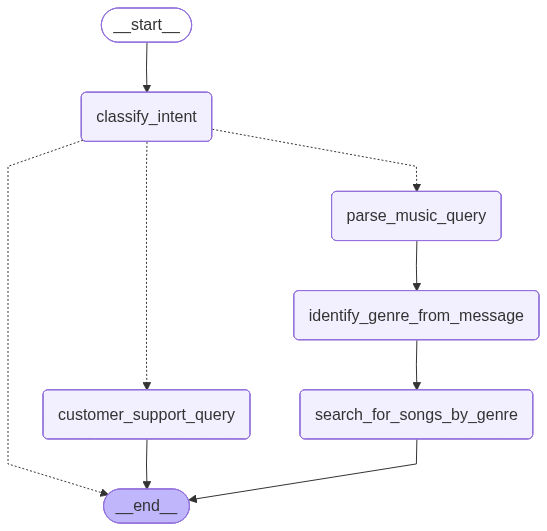

In [31]:
display(Image(graph.get_graph().draw_mermaid_png()))

## Test

In [56]:
# Simulate incoming message
message_id += 1

initial_message = MessageAgentState(
    message_content="Find me music like Prince",
    message_id=message_id,
    sender_number="555-123-1234",
)

config = {"configurable": {"thread_id": str(message_id)}}
result = graph.invoke(initial_message, config=config)

Routing based on classification: intent='music_query'


In [33]:
print(db.run("SELECT * FROM Genre;", include_columns=True))

[{'GenreId': 1, 'Name': 'Rock'}, {'GenreId': 2, 'Name': 'Jazz'}, {'GenreId': 3, 'Name': 'Metal'}, {'GenreId': 4, 'Name': 'Alternative & Punk'}, {'GenreId': 5, 'Name': 'Rock And Roll'}, {'GenreId': 6, 'Name': 'Blues'}, {'GenreId': 7, 'Name': 'Latin'}, {'GenreId': 8, 'Name': 'Reggae'}, {'GenreId': 9, 'Name': 'Pop'}, {'GenreId': 10, 'Name': 'Soundtrack'}, {'GenreId': 11, 'Name': 'Bossa Nova'}, {'GenreId': 12, 'Name': 'Easy Listening'}, {'GenreId': 13, 'Name': 'Heavy Metal'}, {'GenreId': 14, 'Name': 'R&B/Soul'}, {'GenreId': 15, 'Name': 'Electronica/Dance'}, {'GenreId': 16, 'Name': 'World'}, {'GenreId': 17, 'Name': 'Hip Hop/Rap'}, {'GenreId': 18, 'Name': 'Science Fiction'}, {'GenreId': 19, 'Name': 'TV Shows'}, {'GenreId': 20, 'Name': 'Sci Fi & Fantasy'}, {'GenreId': 21, 'Name': 'Drama'}, {'GenreId': 22, 'Name': 'Comedy'}, {'GenreId': 23, 'Name': 'Alternative'}, {'GenreId': 24, 'Name': 'Classical'}, {'GenreId': 25, 'Name': 'Opera'}]
